### SARIMAX
AR(p): model uses its p past values <br>
I(d): differencing d times to remove the trend <br>
MA(q): model uses past forecast errors <br>
S(P, D, Q, s): seasonal lags <br>
X: exogenous variables

---
SARIMAX model for a sample client. Alternative approach is to cluster similar clients and fit one per cluster. 

### 1. Loading and preparing data
Selecting one random client. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import random

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

In [2]:
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

# Same 30 clients as LR and Prophet notebooks
random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())
sampled_clients = random.sample(all_clients, 30)

# ---------------------------------------------------------
# DEBUG MODE: set to True to run on 3 clients only (~2 min vs ~15 min)
# ---------------------------------------------------------
DEBUG_MODE = False
debug_clients = ['MT_328', 'MT_058', 'MT_013']  # one client from different clusters

if DEBUG_MODE:
    sampled_clients = debug_clients
    print(f"DEBUG MODE: running on {len(sampled_clients)} clients: {sampled_clients}")

# Pick first client for EDA (visualization, ACF/PACF, ADF)
sample_client = sampled_clients[0]

print(f"EDA on client {sample_client}, model will run on all {len(sampled_clients)}")
df_sample = df_long[df_long['ClientID'] == sample_client].copy()
df_sample = df_sample.set_index('Date')
df_sample.index = pd.to_datetime(df_sample.index)
df_sample = df_sample.sort_index()
df_sample = df_sample.asfreq("15min")

Loading processed data...
EDA on client MT_328, model will run on all 30


In [3]:
# ---------------------------------------------------------
# Define Target and Exogenous Variables
# ---------------------------------------------------------
y = df_sample['Consumption']
exog = df_sample[[
    'Weekday',
    'Is_Weekend',
    'Is_Holiday',
    'Temp_National_Avg',
    'HDH',
    'CDH',
    'Lag_15min',
    'Lag_24h',
    'Rolling_Mean_4h'
]].astype(float)

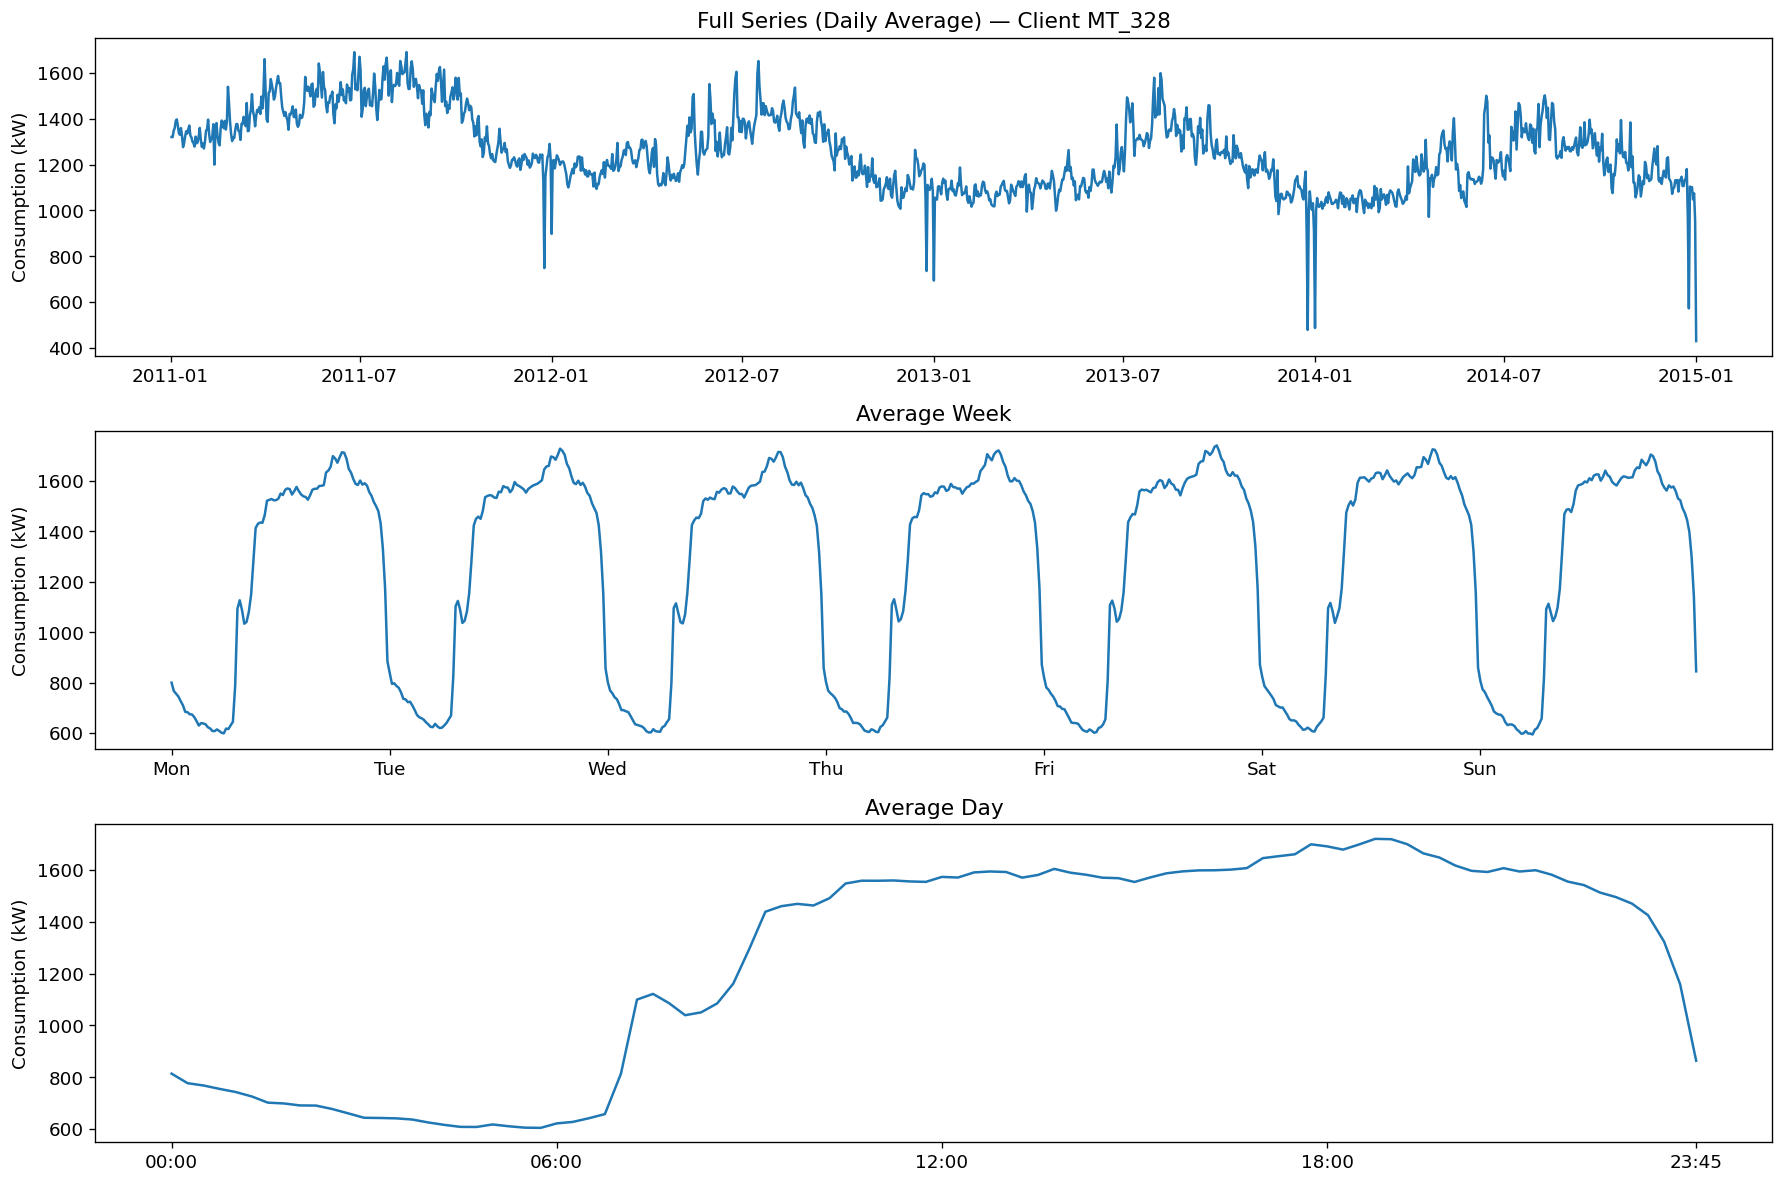

In [4]:
# ---------------------------------------------------------
# Consumption Profile Visualization
# ---------------------------------------------------------
y_with_features = y.to_frame()
y_with_features['dayofweek']   = y.index.dayofweek
y_with_features['time_of_day'] = y.index.hour * 4 + y.index.minute // 15

average_week = y_with_features.groupby(['dayofweek', 'time_of_day'])['Consumption'].mean()
average_day  = y_with_features.groupby('time_of_day')['Consumption'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(y.resample('D').mean())
axes[0].set_title(f"Full Series (Daily Average) — Client {sample_client}")
axes[0].set_ylabel("Consumption (kW)")

axes[1].plot(average_week.values)
axes[1].set_title("Average Week")
axes[1].set_xticks([i * 96 for i in range(7)])
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel("Consumption (kW)")

axes[2].plot(average_day.values)
axes[2].set_title("Average Day")
axes[2].set_xticks([0, 24, 48, 72, 95])
axes[2].set_xticklabels(['00:00', '06:00', '12:00', '18:00', '23:45'])
axes[2].set_ylabel("Consumption (kW)")

plt.tight_layout()
plt.show()

### Seasonality 
In this section we decompose the time series into its trend, seasonal and residual components. Then we conduct an ADF test to see whether the mean drifts.
We can observe seasonality at the daily, weekly and yearly level.

We pick the most granular cycle which is the daily one s=96. 


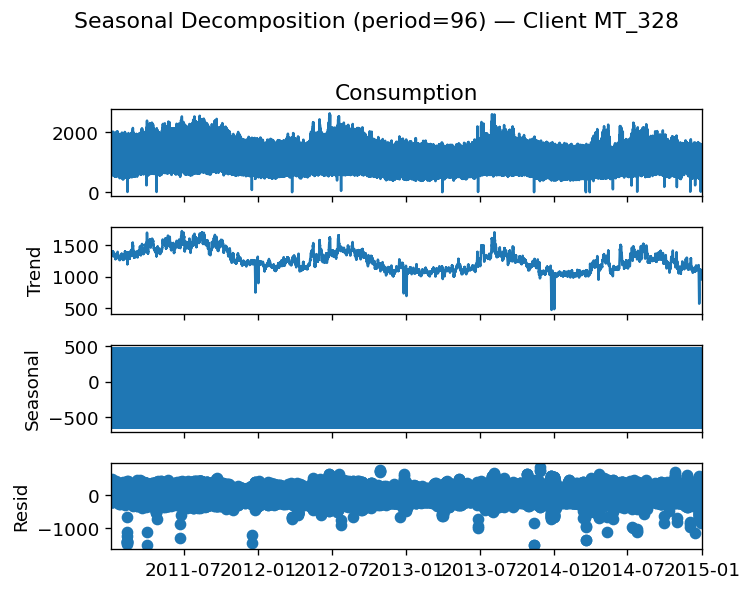

In [5]:
# ---------------------------------------------------------
# Seasonal Decomposition
# ---------------------------------------------------------
decomposition = seasonal_decompose(y, model="additive", period=96)
decomposition.plot()
plt.suptitle(f"Seasonal Decomposition (period=96) — Client {sample_client}", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------
# ADF Stationarity Test
# ---------------------------------------------------------
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n{'='*50}")
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("  Stationary (d=0)")
    else:
        print("  Non-stationary — consider differencing (d=1)")

adf_test(df_sample['Consumption'], f"Client {sample_client}")


ADF Test: Client MT_328
  ADF Statistic : -19.5220
  p-value       : 0.0000
  Stationary (d=0)


### ACF and PACF

ACF shows slow sinusoidal decay — no clean cutoff for q. PACF shows a strong spike at lag 1 then near-zero → p=1, q=1. Spike at lag 96 confirms the daily seasonal period (s=96).

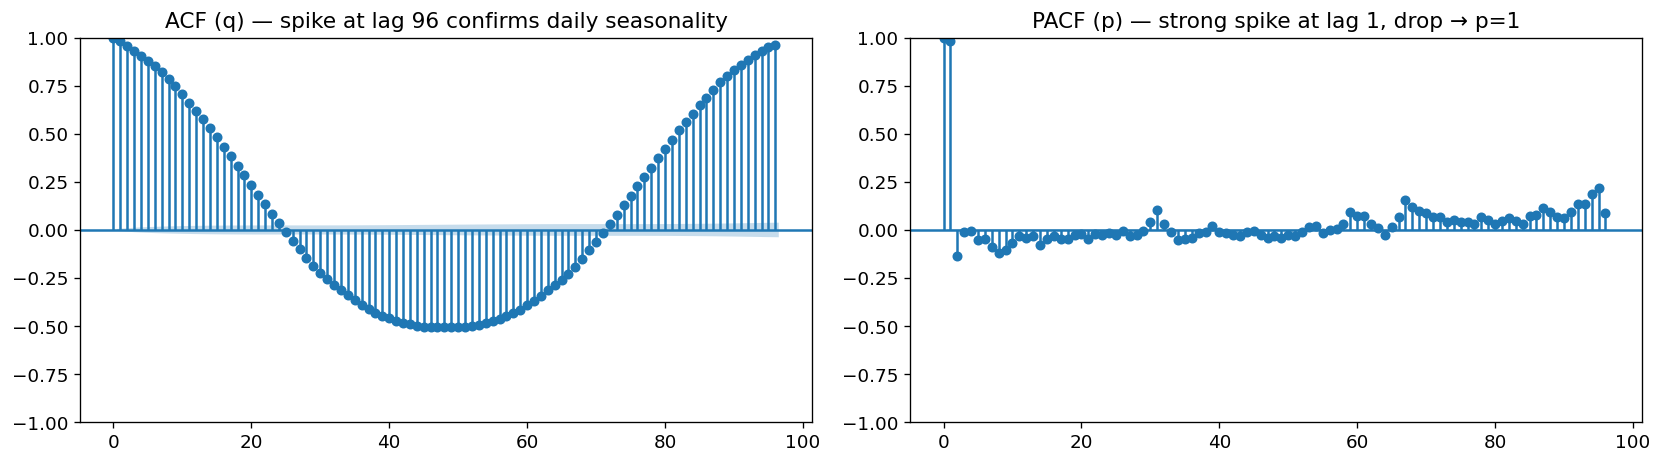

In [7]:
# ---------------------------------------------------------
# ACF and PACF Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=96, ax=axes[0])
axes[0].set_title("ACF (q) — spike at lag 96 confirms daily seasonality")

plot_pacf(y, lags=96, ax=axes[1])
axes[1].set_title("PACF (p) — strong spike at lag 1, drop → p=1")

plt.tight_layout()
plt.show()

In [8]:
# ---------------------------------------------------------
# Model Parameters
# ---------------------------------------------------------
p, d, q    = 1, 0, 1
P, D, Q, s = 1, 0, 1, 96

print(f"Using SARIMAX({p},{d},{q})({P},{D},{Q},{s})")

Using SARIMAX(1,0,1)(1,0,1,96)


### Model Fitting

Parameters selected manually from ACF/PACF plots. `auto_arima` was infeasible at 15-min resolution (s=96) due to memory and runtime constraints. Each of the 30 clients gets its own model fitted on a 4-week training window.

In [9]:
import warnings
warnings.filterwarnings("ignore")

FORECAST_HORIZON = 96
TRAIN_WEEKS      = 4

exog_cols = ['Weekday', 'Is_Weekend', 'Is_Holiday',
             'Temp_National_Avg', 'HDH', 'CDH']

all_maes, all_rmses, all_mapes, all_wmapes = [], [], [], []
failed_clients  = []
all_predictions = {}

for client_id in sampled_clients:
    print(f"Fitting client {client_id}...", end=" ", flush=True)

    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date')
    df_client.index = pd.to_datetime(df_client.index)
    df_client = df_client.sort_index().asfreq("15min")

    y_full      = df_client['Consumption']
    test_start  = len(y_full) - FORECAST_HORIZON
    train_start = test_start - (TRAIN_WEEKS * 7 * 96)

    if train_start < 0:
        print("SKIPPED")
        failed_clients.append(client_id)
        continue

    y_train    = y_full.iloc[train_start:test_start]
    y_test     = y_full.iloc[test_start:]
    exog_full  = df_client[exog_cols].astype(float)
    exog_train = exog_full.iloc[train_start:test_start]
    exog_test  = exog_full.iloc[test_start:]

    try:
        model = SARIMAX(
            y_train, exog=exog_train,
            order=(p, d, q), seasonal_order=(P, D, Q, s),
            enforce_stationarity=False, enforce_invertibility=False
        )
        result = model.fit(disp=False, maxiter=50)

        y_pred = np.maximum(result.forecast(steps=FORECAST_HORIZON, exog=exog_test).values, 0)
        all_predictions[client_id] = y_pred

        y_true = y_test.values
        mae    = mean_absolute_error(y_true, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
        nz     = y_true > 0.1
        mape   = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) if nz.sum() > 0 else 0.0
        wmape  = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) if np.sum(y_true) > 0 else 0.0

        all_maes.append(mae)
        all_rmses.append(rmse)
        all_mapes.append(mape)
        all_wmapes.append(wmape)
        print(f"MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1%}")

    except Exception as e:
        print(f"FAILED: {e}")
        failed_clients.append(client_id)

print(f"\n{'='*50}")
print(f"--- 30-CLIENT SARIMAX BENCHMARK RESULTS ---")
print(f"Clients fitted: {len(all_maes)}/{len(sampled_clients)}")
print(f"Average MAPE:  {np.mean(all_mapes):.2%}")
print(f"Average WMAPE: {np.mean(all_wmapes):.2%}")
print(f"Average MAE:   {np.mean(all_maes):.4f} kW")
print(f"Average RMSE:  {np.mean(all_rmses):.4f} kW")

Fitting client MT_328... MAE=168.54  RMSE=269.61  MAPE=23.9%
Fitting client MT_058... MAE=22.50  RMSE=30.45  MAPE=15.0%
Fitting client MT_013... MAE=24.12  RMSE=26.60  MAPE=57.9%
Fitting client MT_141... MAE=0.31  RMSE=0.38  MAPE=2.9%
Fitting client MT_126... MAE=17.67  RMSE=24.05  MAPE=68.3%
Fitting client MT_115... MAE=5.64  RMSE=7.27  MAPE=27.8%
Fitting client MT_072... MAE=12.55  RMSE=14.83  MAPE=10.8%
Fitting client MT_053... MAE=9.42  RMSE=13.17  MAPE=10.1%
Fitting client MT_347... MAE=0.36  RMSE=0.41  MAPE=0.0%
Fitting client MT_280... MAE=43.81  RMSE=61.54  MAPE=25.8%
Fitting client MT_045... MAE=34.34  RMSE=42.59  MAPE=39.3%
Fitting client MT_303... MAE=26.78  RMSE=36.36  MAPE=20.1%
Fitting client MT_217... MAE=36.08  RMSE=53.52  MAPE=30.2%
Fitting client MT_017... MAE=9.94  RMSE=11.90  MAPE=15.3%
Fitting client MT_016... MAE=13.60  RMSE=16.52  MAPE=20.3%
Fitting client MT_048... MAE=2.88  RMSE=3.31  MAPE=16.1%
Fitting client MT_112... MAE=6.81  RMSE=10.00  MAPE=8.8%
Fitting c

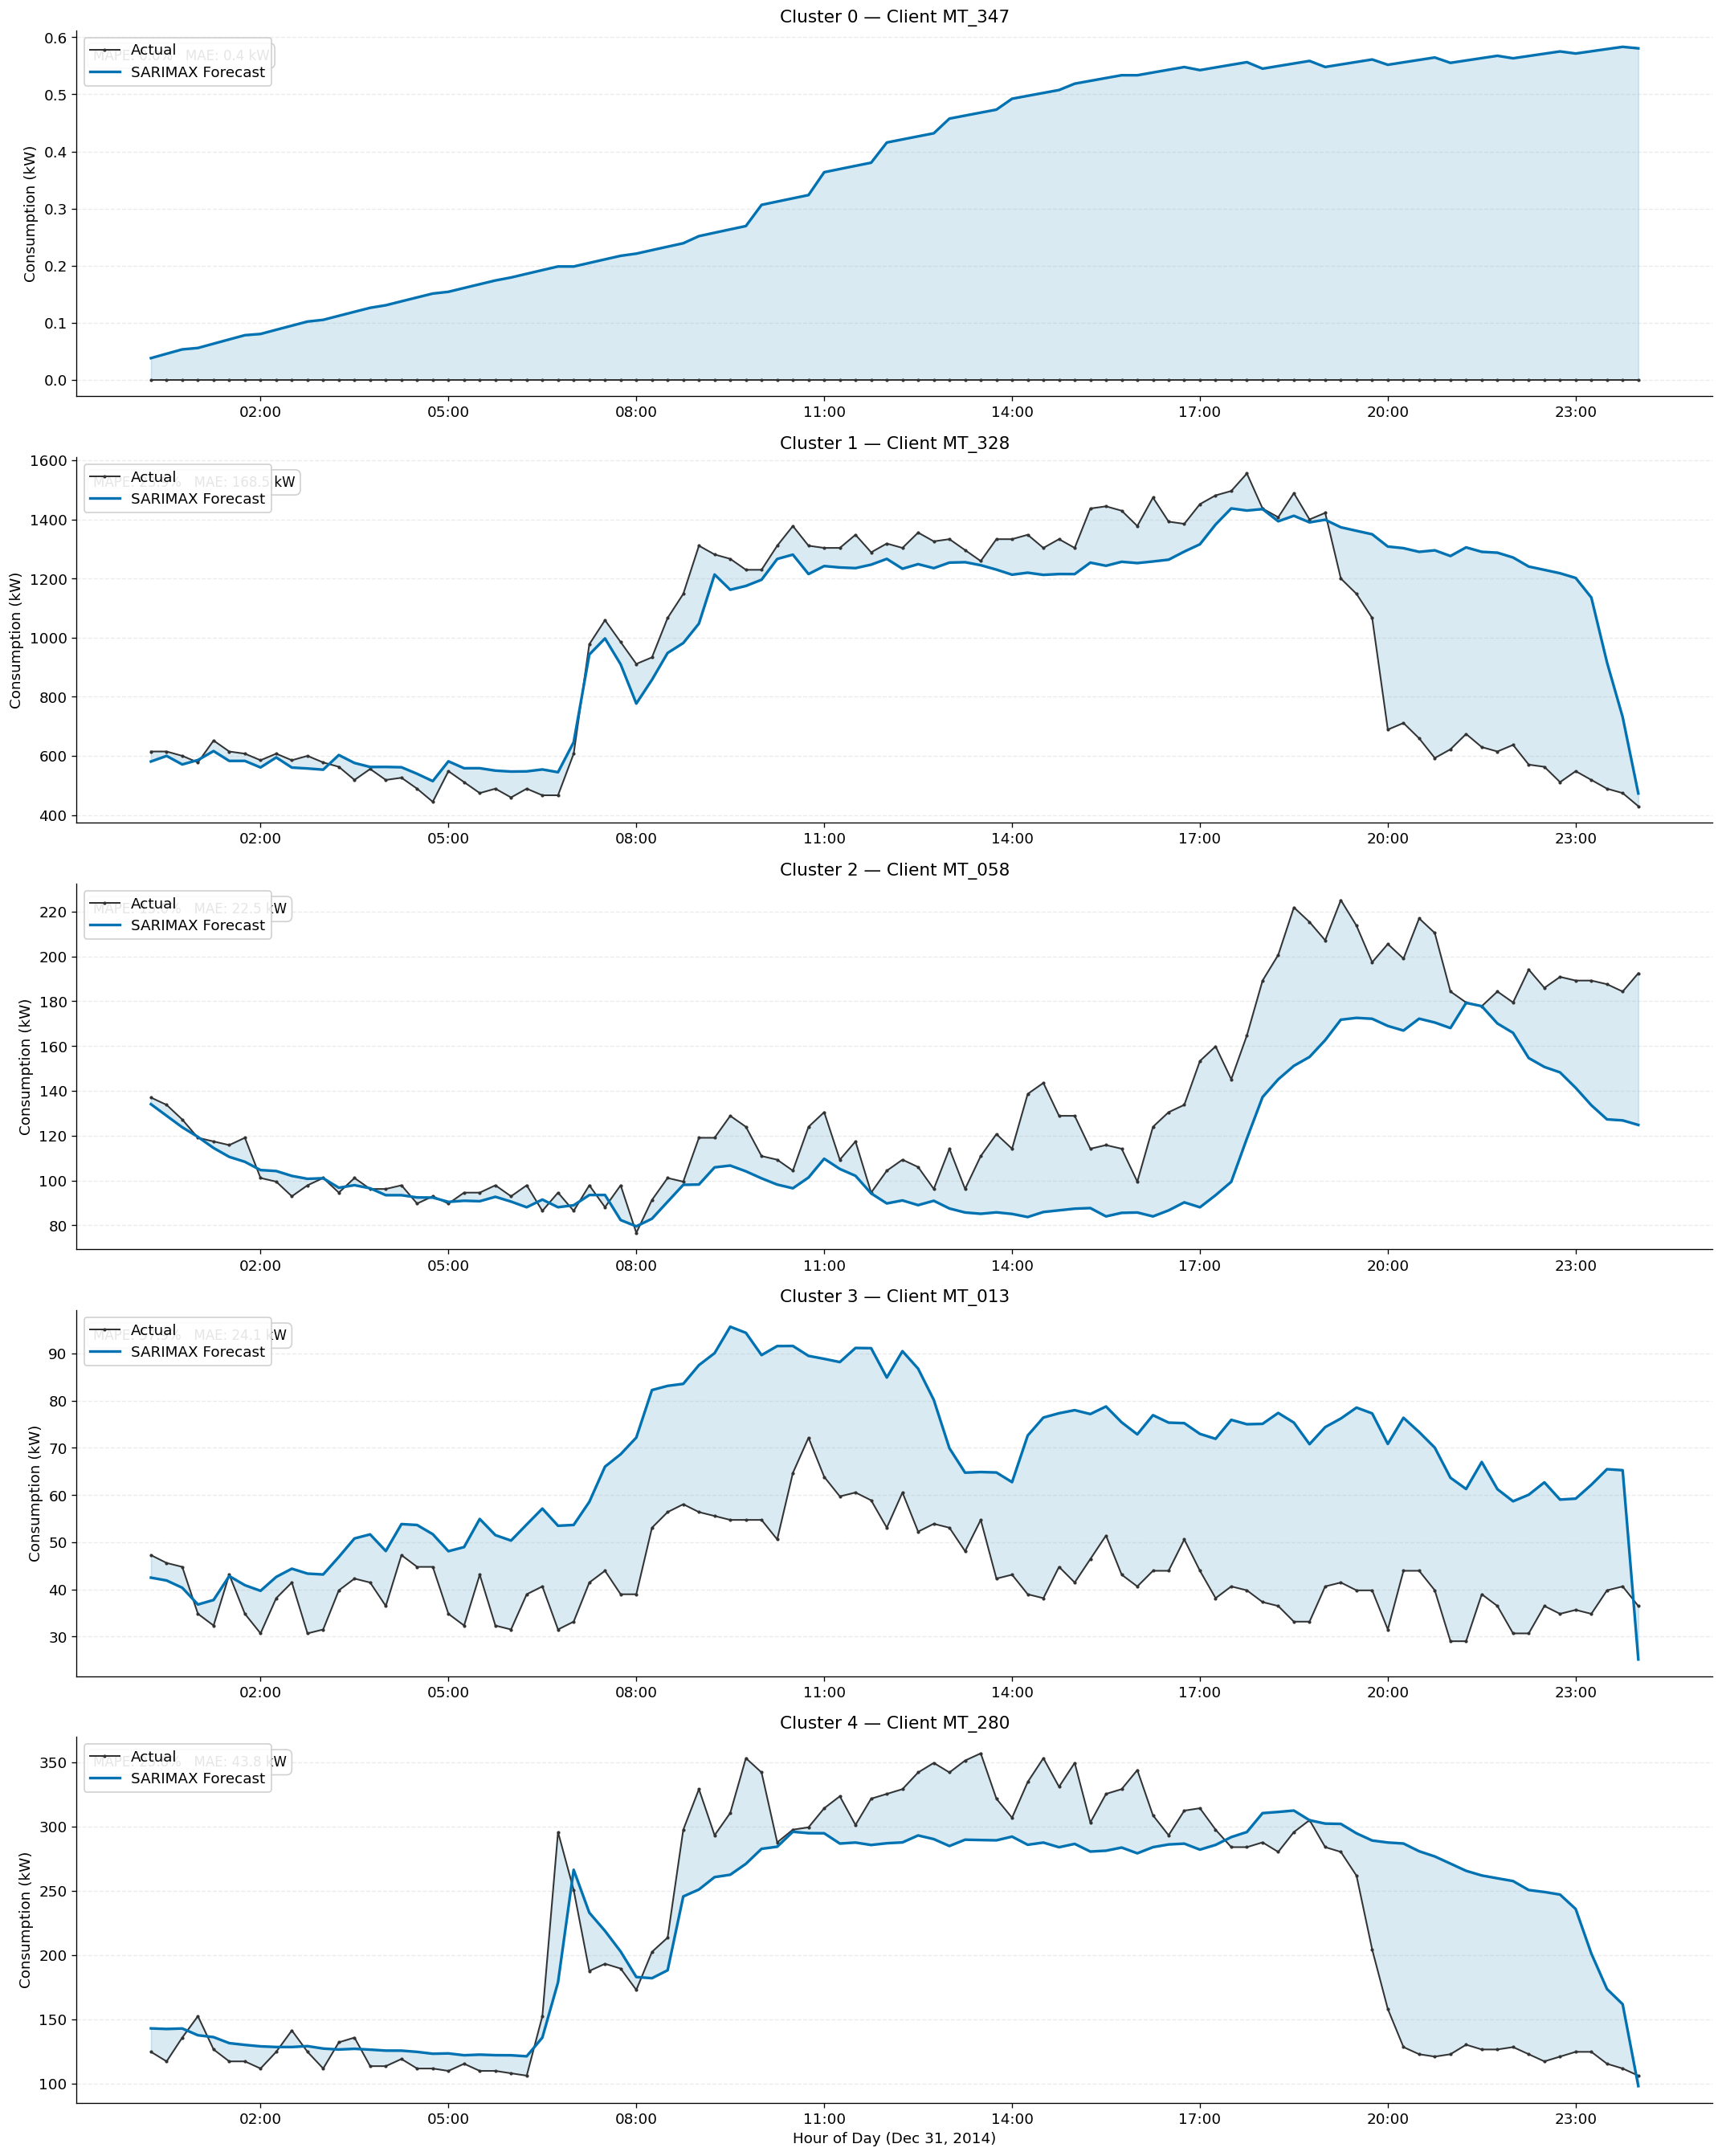

In [10]:
# ---------------------------------------------------------
# Visualization: One Client per Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')

fitted_clients = [c for c in sampled_clients if c not in failed_clients]

vis_df = pd.DataFrame({
    'ClientID': fitted_clients,
    'MAE':   all_maes,
    'RMSE':  all_rmses,
    'MAPE':  all_mapes,
    'WMAPE': all_wmapes,
}).merge(cluster_map, on='ClientID')

cluster_representatives = vis_df.groupby('Cluster')['ClientID'].first().to_dict()

fig, axes = plt.subplots(len(cluster_representatives), 1,
                         figsize=(18, 4.5 * len(cluster_representatives)))
if len(cluster_representatives) == 1:
    axes = [axes]

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx]

    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date')
    df_client.index = pd.to_datetime(df_client.index)
    df_client = df_client.sort_index()

    y_true = df_client['Consumption'].iloc[-FORECAST_HORIZON:].values
    y_pred = all_predictions[client_id]
    x      = df_client.index[-FORECAST_HORIZON:]

    row      = vis_df[vis_df['ClientID'] == client_id].iloc[0]
    mae_val  = row['MAE']
    mape_val = row['MAPE']

    ax.plot(x, y_true, label='Actual', color='#333333', linewidth=1.2,
            marker='.', markersize=3)
    ax.plot(x, y_pred, label='SARIMAX Forecast', color='#0072B2', linewidth=2)
    ax.fill_between(x, y_true, y_pred, alpha=0.15, color='#0072B2')

    ax.text(0.01, 0.95, f"MAPE: {mape_val:.1%}   MAE: {mae_val:.1f} kW",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    ax.set_title(f"Cluster {cluster_id} — Client {client_id}")
    ax.set_ylabel('Consumption (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.grid(False)
    ax.legend(loc='upper left', framealpha=0.9)

axes[-1].set_xlabel('Hour of Day (Dec 31, 2014)')
plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# Performance Breakdown by Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')

sarimax_results_df = pd.DataFrame({
    'ClientID': [c for c in sampled_clients if c not in failed_clients],
    'MAE':   all_maes,
    'RMSE':  all_rmses,
    'MAPE':  all_mapes,
    'WMAPE': all_wmapes
})

sarimax_results_df = sarimax_results_df.merge(cluster_map, on='ClientID')

print("--- SARIMAX PERFORMANCE BY CLUSTER ---\n")
summary = sarimax_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    MAE=('MAE', 'mean'),
    RMSE=('RMSE', 'mean'),
    MAPE=('MAPE', 'mean'),
    WMAPE=('WMAPE', 'mean')
).round(3)
summary['MAPE']  = summary['MAPE'].map('{:.1%}'.format)
summary['WMAPE'] = summary['WMAPE'].map('{:.1%}'.format)
print(summary.to_string())

--- SARIMAX PERFORMANCE BY CLUSTER ---

         n_clients     MAE    RMSE    MAPE  WMAPE
Cluster                                          
0                2  45.788  83.948    6.0%   5.9%
1                7  48.140  73.563   29.0%  21.7%
2                6  21.488  27.339   14.6%  14.5%
3                6   8.894  10.564   21.4%  20.5%
4                9  25.207  32.630  440.7%  31.0%
